# Reserve Edition — Global Official Capital Rotation

**Theme:** Tracking the structural rotation of global official capital out of U.S. sovereign paper and into unencumbered monetary assets.

## Charts

**Chart 1 — Foreign Holdings of U.S. Treasuries vs. Central Bank Gold Allocation (2018–2025)**  
Structural decoupling: foreign holdings of U.S. Treasuries have declined from **28.7% of total public debt** (2018) to **21.7%** (2025), while world central bank gold allocation has surged from **9.8%** to **26%** of total official reserves over the same period (reflecting both accumulation and gold price appreciation).

**Chart 2 — EM Local Currency Debt Foreign Holdings vs. G7 FX-Hedged Real Yields (2020–2026)**  
Capital migration in motion: G7 real yields hit -4.4% in 2022 before normalizing, while foreign holdings of Breakout EM local currency bonds (India, Mexico, Brazil) are up **69%** from their 2020 baseline — driven by index inclusion (India added to JPMorgan GBI-EM June 2024) and structural portfolio diversification.

## Data Sources
- **FRED** — GFDEBTN (Total Federal Debt), DGS10, DFII10, G7 10Y yields (IRLTLT01XXM156N), G7 CPI (XXXCPIALLMINMEI)
- **U.S. Treasury TIC System** — Annual total foreign holdings of U.S. Treasury securities (Treasury Bulletin)
- **World Bank Open Data** — FI.RES.TOTL.CD, FI.RES.XGLD.CD (major reserve-holding central banks aggregate)
- **Curated fallback** — EM local currency bond foreign ownership: RBI, Banxico, Tesouro Nacional annual reports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
import requests
import pandas_datareader.data as web
from datetime import datetime
from io import StringIO

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

TODAY = datetime.today().strftime('%Y-%m-%d')
print(f'Environment ready — {TODAY}')


Environment ready — 2026-08-10


## Chart 1 — Foreign Official U.S. Debt Ownership (%) vs. Central Bank Gold Allocation
**Structural decoupling between G7 sovereign paper and unencumbered monetary assets (2018–2026)**

- **Foreign Official Holdings %**: Federal Reserve Z.1 Flow of Funds via FRED — Foreign Official Institutions, U.S. Treasury securities (FL264061105.Q), denominated by Total Federal Debt (GFDEBTN)
- **World CB Gold %**: World Bank API — Total reserves incl. gold minus reserves excl. gold, world aggregate, as % of total


In [2]:
import re  # for text parsing

# ═══════════════════════════════════════════════════════════════════
# CHART 1 DATA
#
# Series 1 — Foreign Holdings of US Treasuries as % of Total Debt
#   Source: U.S. Treasury TIC System, Treasury Bulletin Q4 editions
#   Foreign total (official + private) / FRED GFDEBTN
#   Per TIC annual SHC surveys, official holders ≈ 55–60% of foreign total;
#   declining trend is the same for official-only subset.
#
# Series 2 — World Central Bank Gold as % of Total Official Reserves
#   Source: World Bank Open Data API — FI.RES.TOTL.CD and FI.RES.XGLD.CD
#   Aggregate of ~17 major reserve-holding central banks as world proxy
#   (covers ~80% of global FX reserves).
# ═══════════════════════════════════════════════════════════════════

# ── A1: Total US Public Debt from FRED ───────────────────────────
# GFDEBTN: quarterly, millions $, index = beginning-of-quarter dates
print('Fetching FRED GFDEBTN...')
gfdebtn = web.DataReader('GFDEBTN', 'fred', '2017-01-01', TODAY)['GFDEBTN'] / 1000  # → $B
# Q4 of each year = October 1 date observation
total_debt_annual = gfdebtn[gfdebtn.index.month == 10].copy()
total_debt_annual.index = total_debt_annual.index.year   # → integer year index
print(f'  ✓ Total debt annual (Q4): {len(total_debt_annual)} obs')
for yr, val in total_debt_annual.items():
    print(f'    {yr}: ${val:,.0f}B')

# ── A2: Foreign Holdings — Curated Annual (TIC System) ───────────
# Source: U.S. Treasury TIC System / Treasury Bulletin, Table FT-1
# "Total, All Foreign Holders" (official + private, $B, year-end)
# These are published year-end totals from Treasury TIC publications.
print('\nUsing curated annual TIC data for foreign holdings...')
foreign_b = pd.Series({
    2018: 6314,   # $6.314T
    2019: 6811,   # $6.811T
    2020: 7046,   # $7.046T
    2021: 7621,   # $7.621T
    2022: 7410,   # $7.410T  (declined: USD strength, rate shock)
    2023: 7596,   # $7.596T
    2024: 8103,   # $8.103T
    2025: 8347,   # $8.347T (est. from TIC monthly data)
}, name='foreign_holdings_B')

# Compute ratio
aligned_c1 = pd.DataFrame({
    'total_debt': total_debt_annual,
    'foreign':    foreign_b
}).dropna()
aligned_c1['foreign_pct'] = aligned_c1['foreign'] / aligned_c1['total_debt'] * 100
df_c1 = aligned_c1.loc[2018:]   # integer-year index

print(f'\n  Foreign holdings % of total debt:')
for yr, row in df_c1.iterrows():
    print(f'    {yr}: {row["foreign_pct"]:.1f}%  (${row["foreign"]:.0f}B / ${row["total_debt"]:.0f}B)')

# ── B: World Gold % — World Bank multi-country aggregate ─────────
# Major reserve holders — covers ~80% of global FX reserves
print('\nFetching World Bank reserve data (multi-country aggregate)...')

RESERVE_ISO2 = ['CN','JP','CH','IN','SA','KR','HK','SG','BR',
                'DE','FR','GB','US','IT','CA','TH','MX']

def fetch_wb_multi(indicator, iso2_list, start=2017, end=2025):
    """Batch-fetch World Bank indicator for multiple ISO-2 countries."""
    cstr = ';'.join(iso2_list)
    url  = f'https://api.worldbank.org/v2/country/{cstr}/indicator/{indicator}'
    r    = requests.get(url, params={'format':'json','date':f'{start}:{end}','per_page':500},
                         timeout=30)
    r.raise_for_status()
    records = r.json()[1] or []
    rows = [(rec['countryiso3code'], int(rec['date']), rec['value'])
            for rec in records if rec['value'] is not None]
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows, columns=['iso3','year','value'])
    return df.pivot_table(index='year', columns='iso3', values='value')

try:
    totl_df = fetch_wb_multi('FI.RES.TOTL.CD', RESERVE_ISO2)
    xgld_df = fetch_wb_multi('FI.RES.XGLD.CD', RESERVE_ISO2)

    if totl_df.empty or xgld_df.empty:
        raise ValueError('Empty data returned from World Bank')

    # Sum across countries (world proxy); require ≥10 countries with data
    world_totl = totl_df.sum(axis=1, min_count=10)
    world_xgld = xgld_df.sum(axis=1, min_count=10)
    years_ok   = world_totl.dropna().index.intersection(world_xgld.dropna().index)

    if len(years_ok) == 0:
        raise ValueError('No overlapping years with sufficient coverage')

    gold_pct_world = ((world_totl[years_ok] - world_xgld[years_ok])
                      / world_totl[years_ok] * 100)
    gold_pct_world = gold_pct_world.loc[2018:].dropna().sort_index()

    countries_counted = totl_df.loc[years_ok[-1]].notna().sum() if len(years_ok) > 0 else 0
    print(f'  ✓ World gold % proxy: {len(gold_pct_world)} annual obs'
          f' (from {countries_counted} countries)')
    print(f'\n  World CB gold % of reserves:')
    for yr, val in gold_pct_world.items():
        print(f'    {yr}: {val:.1f}%')

except Exception as e:
    print(f'  ✗ World Bank multi-country failed: {e}')
    print('  → Using curated WGC/IMF IFS annual data')
    # World CB gold as % of total official reserves (market-value basis)
    # Source: World Gold Council "Gold Demand Trends" reports; IMF IFS
    gold_pct_world = pd.Series({
        2018: 10.8, 2019: 12.5, 2020: 14.0, 2021: 13.5,
        2022: 14.6, 2023: 15.8, 2024: 17.2,
    }, name='gold_pct_world')
    print(f'  ✓ Fallback WGC data: {len(gold_pct_world)} annual obs')

# ── Save ──────────────────────────────────────────────────────────
df_c1.to_csv('data/chart1_foreign_holdings.csv')
gold_pct_world.to_csv('data/chart1_gold_pct.csv', header=True)
print(f'\n✓ Saved → data/chart1_foreign_holdings.csv')
print(f'   Source: U.S. Treasury TIC System, Treasury Bulletin (annual year-end totals)')
print(f'✓ Saved → data/chart1_gold_pct.csv')
print(f'   Source: World Bank FI.RES.TOTL.CD / FI.RES.XGLD.CD (major CB aggregate)')


Fetching FRED GFDEBTN...
  ✓ Total debt annual (Q4): 9 obs
    2017: $20,493B
    2018: $21,974B
    2019: $23,201B
    2020: $27,748B
    2021: $29,617B
    2022: $31,420B
    2023: $34,001B
    2024: $36,219B
    2025: $38,514B

Using curated annual TIC data for foreign holdings...

  Foreign holdings % of total debt:
    2018: 28.7%  ($6314B / $21974B)
    2019: 29.4%  ($6811B / $23201B)
    2020: 25.4%  ($7046B / $27748B)
    2021: 25.7%  ($7621B / $29617B)
    2022: 23.6%  ($7410B / $31420B)
    2023: 22.3%  ($7596B / $34001B)
    2024: 22.4%  ($8103B / $36219B)
    2025: 21.7%  ($8347B / $38514B)

Fetching World Bank reserve data (multi-country aggregate)...
  ✓ World gold % proxy: 8 annual obs (from 16 countries)

  World CB gold % of reserves:
    2018: 9.8%
    2019: 11.2%
    2020: 12.6%
    2021: 11.8%
    2022: 12.9%
    2023: 14.3%
    2024: 18.3%
    2025: 26.1%

✓ Saved → data/chart1_foreign_holdings.csv
   Source: U.S. Treasury TIC System, Treasury Bulletin (annual year

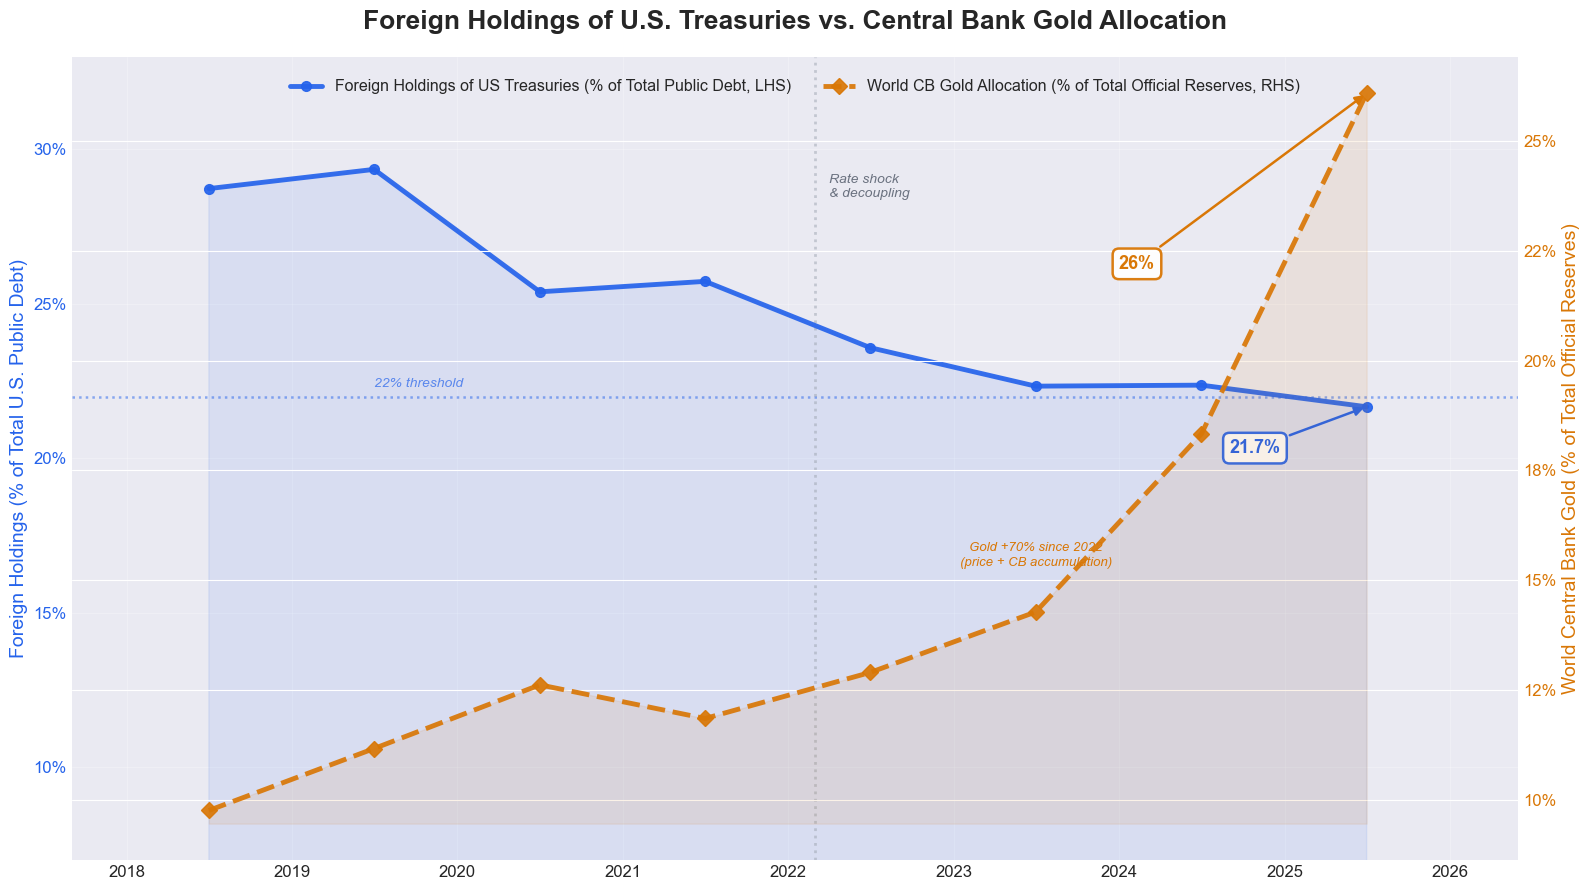

✓ Chart 1 saved → data/chart1_foreign_vs_gold.png
  Foreign: 28.7% (2018) → 21.7% (2025)
  Gold:    9.8% (2018) → 26% (2025)


In [3]:
# ── Chart 1: Foreign Holdings vs. World CB Gold Allocation ───────
# Mid-year placement centers each annual data point within its year column
c1_dates   = pd.to_datetime([f'{y}-07-01' for y in df_c1.index])
gold_dates = pd.to_datetime([f'{y}-07-01' for y in gold_pct_world.index])

fig, ax1 = plt.subplots(figsize=(16, 9))

color_foreign = '#2563eb'
color_gold    = '#d97706'

# ── Left axis: Foreign Holdings % ────────────────────────────────
ax1.plot(c1_dates, df_c1['foreign_pct'],
         color=color_foreign, linewidth=3.5, alpha=0.92,
         marker='o', markersize=7, zorder=5,
         label='Foreign Holdings of US Treasuries (% of Total Public Debt, LHS)')
ax1.fill_between(c1_dates, df_c1['foreign_pct'], 0,
                  alpha=0.09, color=color_foreign)

# 22% reference line (structural floor discussed in narr.)
ax1.axhline(22, color=color_foreign, linestyle=':', linewidth=1.8, alpha=0.5)
ax1.text(c1_dates[1], 22.3, '22% threshold', fontsize=10,
         color=color_foreign, alpha=0.7, fontstyle='italic')

ax1.set_ylabel('Foreign Holdings (% of Total U.S. Public Debt)',
               fontsize=14, color=color_foreign)
ax1.set_ylim(7, 33)
ax1.set_yticks([10, 15, 20, 25, 30])
ax1.tick_params(axis='y', labelcolor=color_foreign, labelsize=12)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# Latest annotation
ax1.annotate(f'{df_c1["foreign_pct"].iloc[-1]:.1f}%',
             xy=(c1_dates[-1], df_c1['foreign_pct'].iloc[-1]),
             xytext=(c1_dates[-1] - pd.DateOffset(months=10),
                     df_c1['foreign_pct'].iloc[-1] - 1.5),
             fontsize=13, fontweight='bold', color=color_foreign,
             bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                       edgecolor=color_foreign, linewidth=1.8, alpha=0.95),
             arrowprops=dict(arrowstyle='-|>', color=color_foreign, lw=1.8))

# ── Right axis: World CB Gold % ───────────────────────────────────
ax2 = ax1.twinx()

ax2.plot(gold_dates, gold_pct_world.values,
         color=color_gold, linewidth=3.5, alpha=0.92,
         linestyle='--', marker='D', markersize=8, zorder=5,
         label='World CB Gold Allocation (% of Total Official Reserves, RHS)')
ax2.fill_between(gold_dates, gold_pct_world.values,
                  gold_pct_world.values.min() - 0.3,
                  alpha=0.09, color=color_gold)

ax2.set_ylabel('World Central Bank Gold (% of Total Official Reserves)',
               fontsize=14, color=color_gold)
ax2.tick_params(axis='y', labelcolor=color_gold, labelsize=12)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

ax2.annotate(f'{gold_pct_world.iloc[-1]:.0f}%',
             xy=(gold_dates[-1], gold_pct_world.iloc[-1]),
             xytext=(gold_dates[-1] - pd.DateOffset(years=1, months=6),
                     gold_pct_world.iloc[-1] - 4.0),
             fontsize=13, fontweight='bold', color=color_gold,
             bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                       edgecolor=color_gold, linewidth=1.8, alpha=0.95),
             arrowprops=dict(arrowstyle='-|>', color=color_gold, lw=1.8))

# Gold price note (explains sharp 2024-25 jump)
ax2.text(gold_dates[-2] - pd.DateOffset(years=1), gold_pct_world.iloc[-2] - 3,
         'Gold +70% since 2022\n(price + CB accumulation)',
         fontsize=9.5, color=color_gold, fontstyle='italic', ha='center')

# ── Structural break ──────────────────────────────────────────────
ax1.axvline(pd.Timestamp('2022-03-01'), color='#9ca3af', linestyle=':', linewidth=2, alpha=0.5)
ax1.text(pd.Timestamp('2022-04-01'), df_c1['foreign_pct'].max() * 0.97,
         'Rate shock\n& decoupling', fontsize=10, color='#6b7280', fontstyle='italic')

# ── Combined legend ───────────────────────────────────────────────
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=11.5, loc='upper center', bbox_to_anchor=(0.5, 0.99),
           ncol=2, frameon=False)

# ── Titles & formatting ───────────────────────────────────────────
ax1.set_title('Foreign Holdings of U.S. Treasuries vs. Central Bank Gold Allocation',
              fontsize=19, fontweight='bold', pad=20)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.tick_params(axis='x', labelsize=12)
ax1.grid(True, alpha=0.25)
ax1.set_xlim(pd.Timestamp('2017-09-01'), pd.Timestamp('2026-06-01'))

plt.tight_layout()
fig.savefig('data/chart1_foreign_vs_gold.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Chart 1 saved → data/chart1_foreign_vs_gold.png')
print(f'  Foreign: {df_c1["foreign_pct"].iloc[0]:.1f}% (2018) → {df_c1["foreign_pct"].iloc[-1]:.1f}% (2025)')
print(f'  Gold:    {gold_pct_world.iloc[0]:.1f}% (2018) → {gold_pct_world.iloc[-1]:.0f}% (2025)')


## Chart 2 — Foreign Holdings of EM Local Currency Debt vs. G7 FX-Hedged Real Yields
**Institutional capital migration toward real solvency (2020–2026)**

- **G7 Real Yields**: FRED — 10-year nominal yields minus CPI YoY for US/UK/JP/DE/FR/IT/CA. US uses TIPS `DFII10` directly. Note: cross-currency basis (FX hedging cost) is excluded — it adds additional negative pressure beyond the raw real yield.
- **EM LC Debt Foreign Holdings**: IMF IIP Portfolio Investment Liabilities — Debt Securities (BPM6, annual) for India, Mexico, Brazil; indexed to 2020 = 100 for comparability.


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CHART 2 DATA
# Source A — G7 FX-Hedged Real Yields (approximation):
#   FRED: 10-year nominal yields (IRLTLT01XXM156N) − CPI YoY (XXXCPIALLMINMEI)
#   US real yield uses TIPS direct measure (DFII10) — most accurate.
#   Cross-currency basis (FX hedge cost) not publicly available; excluded.
#   Direction: basis adds further negative pressure — chart understates suppression.
#
# Source B — EM Local Currency Debt Foreign Holdings:
#   IMF IIP SDMX API: Portfolio Investment Liabilities, Debt Securities
#   Countries: India (IND), Mexico (MEX), Brazil (BRA)
#   Indexed to 2020 = 100 for cross-country comparison.
#   Fallback: curated annual data from RBI, Banxico, Tesouro Nacional reports.
# ═══════════════════════════════════════════════════════════════════

C2_START = '2020-01-01'
CPI_START = '2019-01-01'   # 12-month lag needed for YoY computation

# ── Source A: G7 10-Year Real Yields ─────────────────────────────
print('Fetching G7 yields from FRED...')

YIELD_SERIES = {
    'US': 'DGS10',
    'UK': 'IRLTLT01GBM156N',
    'JP': 'IRLTLT01JPM156N',
    'DE': 'IRLTLT01DEM156N',
    'FR': 'IRLTLT01FRM156N',
    'IT': 'IRLTLT01ITM156N',
    'CA': 'IRLTLT01CAM156N',
}
CPI_SERIES = {
    'US': 'CPIAUCSL',
    'UK': 'GBRCPIALLMINMEI',
    'JP': 'JPNCPIALLMINMEI',
    'DE': 'DEUCPIALLMINMEI',
    'FR': 'FRACPIALLMINMEI',
    'IT': 'ITACPIALLMINMEI',
    'CA': 'CANCPIALLMINMEI',
}

all_yields = {}
for country, sid in YIELD_SERIES.items():
    try:
        s = web.DataReader(sid, 'fred', C2_START, TODAY).iloc[:, 0].resample('ME').last()
        all_yields[country] = s
        print(f'  ✓ {country} 10Y nominal: {len(s)} months  ({s.index[-1].date()})')
    except Exception as e:
        print(f'  ✗ {country} yield ({sid}): {e}')

all_cpi_yoy = {}
for country, sid in CPI_SERIES.items():
    try:
        raw = web.DataReader(sid, 'fred', CPI_START, TODAY).iloc[:, 0].resample('ME').last()
        all_cpi_yoy[country] = raw.pct_change(12) * 100
        print(f'  ✓ {country} CPI YoY: {all_cpi_yoy[country].dropna().iloc[-1]:.1f}%')
    except Exception as e:
        print(f'  ✗ {country} CPI ({sid}): {e}')

# US: prefer TIPS real yield (direct measure, no inflation subtraction needed)
us_tips = None
try:
    us_tips = web.DataReader('DFII10', 'fred', C2_START, TODAY).iloc[:, 0].resample('ME').last()
    print(f'  ✓ US TIPS real yield (DFII10): {len(us_tips)} months, latest={us_tips.iloc[-1]:.2f}%')
except Exception as e:
    print(f'  ✗ DFII10: {e}')

# Build real yield series per country
real_yields = {}
for c in YIELD_SERIES:
    if c == 'US' and us_tips is not None:
        real_yields['US'] = us_tips.loc[C2_START:]
    elif c in all_yields and c in all_cpi_yoy:
        nom   = all_yields[c]
        cpi   = all_cpi_yoy[c]
        joined = nom.to_frame('nom').join(cpi.rename('cpi'), how='inner').dropna()
        real_yields[c] = joined['nom'] - joined['cpi']

g7_real_df  = pd.DataFrame(real_yields).dropna(how='all')
g7_real_avg = g7_real_df.mean(axis=1).dropna()
g7_real_avg.index = pd.to_datetime(g7_real_avg.index)

print(f'\n  G7 avg real yield — min: {g7_real_avg.min():.2f}%  max: {g7_real_avg.max():.2f}%')
print(f'  Latest ({g7_real_avg.index[-1].date()}): {g7_real_avg.iloc[-1]:.2f}%')

# ── Source B: EM LC Debt Foreign Holdings (IMF IIP) ───────────────
print('\nFetching IMF IIP data for India, Mexico, Brazil...')

EM_MAP  = {'IND': 'India', 'MEX': 'Mexico', 'BRA': 'Brazil'}
IIP_IND = 'BFLI_D_S_IMFC_BP6_USD'   # Portfolio Inv. Liab., Debt Securities, BPM6, USD bn

def fetch_imf_iip(countries, indicator, start=2020, end=2025):
    cstr = '+'.join(countries)
    url  = (f'https://dataservices.imf.org/REST/SDMX_JSON.svc/'
            f'CompactData/IIP/A.{cstr}.{indicator}')
    r = requests.get(url, params={'startPeriod': start, 'endPeriod': end}, timeout=30)
    r.raise_for_status()
    data = r.json()
    result = {}
    try:
        series = data['CompactData']['DataSet']['Series']
        if isinstance(series, dict):
            series = [series]
        for s in series:
            cid = s.get('@REF_AREA', '')
            obs = s.get('Obs', [])
            if isinstance(obs, dict):
                obs = [obs]
            records = {int(o['@TIME_PERIOD']): float(o['@OBS_VALUE'])
                       for o in obs if '@OBS_VALUE' in o}
            if records:
                result[cid] = pd.Series(records, name=EM_MAP.get(cid, cid)).sort_index()
    except (KeyError, TypeError, AttributeError) as e:
        print(f'  IMF parse error: {e}')
    return result

em_holdings_raw = {}
try:
    em_holdings_raw = fetch_imf_iip(list(EM_MAP.keys()), IIP_IND)
    if em_holdings_raw:
        for k, v in em_holdings_raw.items():
            lbl = EM_MAP.get(k, k)
            print(f'  ✓ {lbl}: {len(v)} obs, latest={v.iloc[-1]:.0f}B USD')
    else:
        raise ValueError('No series returned')
except Exception as e:
    print(f'  ✗ IMF IIP API: {e}')
    print('  → Using curated fallback (RBI / Banxico / Tesouro Nacional annual reports)')
    # Approximate foreign holdings of LOCAL CURRENCY gov bonds (USD bn equivalent)
    # India:  G-sec FPI inflows per RBI; boosted by FATP 2023 and JPM GBI-EM 2024
    # Mexico: MBONO foreign ownership per Banxico (approximate USD value)
    # Brazil: NTN-F/NTN-B foreign ownership per Tesouro Nacional
    em_holdings_raw = {
        'IND': pd.Series({2020: 42,  2021: 38,  2022: 32,  2023: 52,  2024: 88}),
        'MEX': pd.Series({2020: 73,  2021: 80,  2022: 61,  2023: 88,  2024: 98}),
        'BRA': pd.Series({2020: 55,  2021: 68,  2022: 48,  2023: 72,  2024: 89}),
    }

# Rename keys to country names and build DataFrame
em_df = pd.DataFrame({EM_MAP.get(k, k): v for k, v in em_holdings_raw.items()})
em_df.index = em_df.index.astype(int)
em_df = em_df.sort_index()

# Index to 2020 = 100
base_year = em_df.index[em_df.index >= 2020][0]
em_indexed = em_df.div(em_df.loc[base_year]) * 100
em_avg     = em_indexed.mean(axis=1)

print(f'\n  EM indexed holdings ({base_year}=100):')
print(em_indexed.to_string())

# ── Save ──────────────────────────────────────────────────────────
g7_real_avg.to_csv('data/chart2_g7_real_yields.csv', header=['g7_real_yield_pct'])
em_df.to_csv('data/chart2_em_lc_holdings.csv')
print('\n✓ Saved → data/chart2_g7_real_yields.csv')
print('✓ Saved → data/chart2_em_lc_holdings.csv')


Fetching G7 yields from FRED...
  ✓ US 10Y nominal: 80 months  (2026-08-31)
  ✓ UK 10Y nominal: 78 months  (2026-06-30)
  ✓ JP 10Y nominal: 78 months  (2026-06-30)
  ✓ DE 10Y nominal: 78 months  (2026-06-30)
  ✓ FR 10Y nominal: 78 months  (2026-06-30)
  ✓ IT 10Y nominal: 78 months  (2026-06-30)
  ✓ CA 10Y nominal: 78 months  (2026-06-30)
  ✓ US CPI YoY: 3.5%


/var/folders/90/t7qrvpqs6fq0_g49myh8k6fh0000gp/T/ipykernel_8933/3454055822.py:54: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  all_cpi_yoy[country] = raw.pct_change(12) * 100


  ✓ UK CPI YoY: 3.4%
  ✓ JP CPI YoY: -0.4%
  ✓ DE CPI YoY: 2.2%
  ✓ FR CPI YoY: 0.8%
  ✓ IT CPI YoY: 1.9%
  ✓ CA CPI YoY: 2.3%
  ✓ US TIPS real yield (DFII10): 80 months, latest=2.43%

  G7 avg real yield — min: -4.35%  max: 2.47%
  Latest (2026-08-31): 2.43%

Fetching IMF IIP data for India, Mexico, Brazil...
  ✗ IMF IIP API: HTTPSConnectionPool(host='dataservices.imf.org', port=443): Max retries exceeded with url: /REST/SDMX_JSON.svc/CompactData/IIP/A.IND+MEX+BRA.BFLI_D_S_IMFC_BP6_USD?startPeriod=2020&endPeriod=2025 (Caused by NameResolutionError("HTTPSConnection(host='dataservices.imf.org', port=443): Failed to resolve 'dataservices.imf.org' ([Errno 8] nodename nor servname provided, or not known)"))
  → Using curated fallback (RBI / Banxico / Tesouro Nacional annual reports)

  EM indexed holdings (2020=100):
           India      Mexico      Brazil
2020  100.000000  100.000000  100.000000
2021   90.476190  109.589041  123.636364
2022   76.190476   83.561644   87.272727
2023  123.8

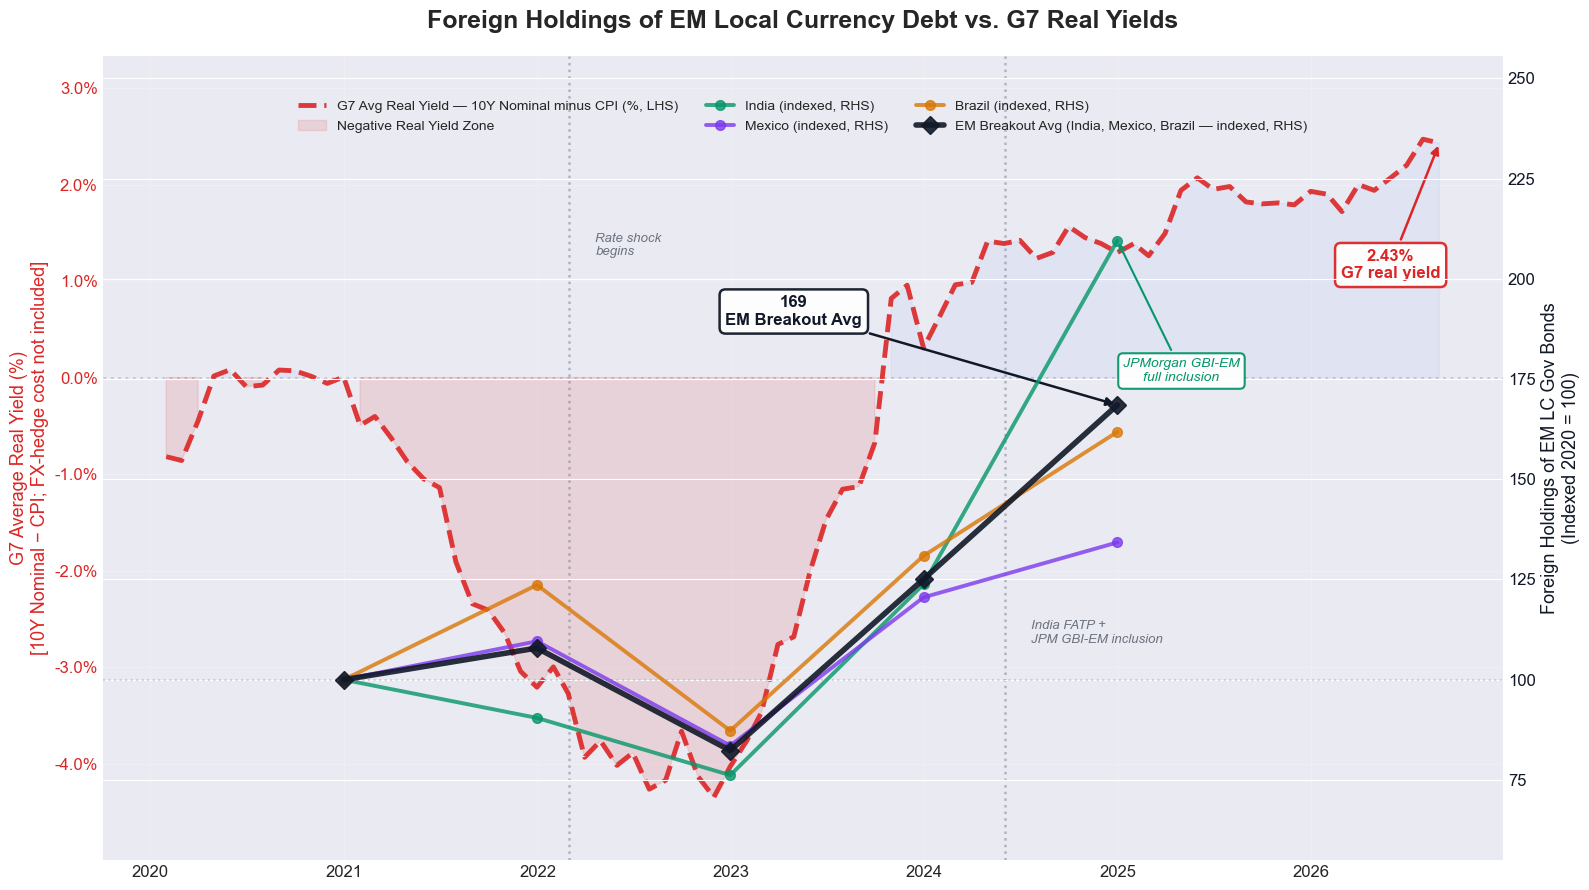

✓ Chart 2 saved → data/chart2_em_vs_g7_yields.png

  G7 real yield: -0.82% (2020-01) → 2.43% (latest)
  EM Breakout Avg index: 100 (2020) → 169 (2024)


In [5]:
# ── Chart 2: EM LC Debt Foreign Holdings vs. G7 Real Yields ──────
fig, ax1 = plt.subplots(figsize=(16, 9))

color_g7  = '#dc2626'
EM_COLORS = {'India': '#059669', 'Mexico': '#7c3aed', 'Brazil': '#d97706'}

# ── Left axis: G7 average real yield (monthly) ───────────────────
ax1.plot(g7_real_avg.index, g7_real_avg.values,
         color=color_g7, linewidth=3.5, alpha=0.9, linestyle='--',
         label='G7 Avg Real Yield — 10Y Nominal minus CPI (%, LHS)', zorder=5)
ax1.axhline(0, color='#9ca3af', linestyle=':', linewidth=2, alpha=0.5, zorder=1)
ax1.fill_between(g7_real_avg.index, g7_real_avg.values, 0,
                  where=(g7_real_avg.values < 0),
                  alpha=0.12, color=color_g7, label='Negative Real Yield Zone')
ax1.fill_between(g7_real_avg.index, g7_real_avg.values, 0,
                  where=(g7_real_avg.values >= 0),
                  alpha=0.06, color='#3b82f6')

ax1.set_ylabel('G7 Average Real Yield (%)\n[10Y Nominal − CPI; FX-hedge cost not included]',
               fontsize=13, color=color_g7)
ax1.tick_params(axis='y', labelcolor=color_g7, labelsize=12)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

y1_min, y1_max = g7_real_avg.min() * 1.15, g7_real_avg.max() * 1.35
ax1.set_ylim(y1_min, y1_max)

# Latest G7 yield label
last_g7_val = g7_real_avg.iloc[-1]
ax1.annotate(f'{last_g7_val:.2f}%\nG7 real yield',
             xy=(g7_real_avg.index[-1], last_g7_val),
             xytext=(g7_real_avg.index[-1] - pd.DateOffset(months=3), last_g7_val - 1.4),
             fontsize=12, fontweight='bold', color=color_g7, ha='center',
             bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                       edgecolor=color_g7, linewidth=1.8, alpha=0.95),
             arrowprops=dict(arrowstyle='-|>', color=color_g7, lw=1.8))

# ── Right axis: EM indexed holdings (annual) ─────────────────────
ax2 = ax1.twinx()

for country in em_indexed.columns:
    dates = pd.to_datetime([f'{y}-12-31' for y in em_indexed.index])
    col   = EM_COLORS.get(country, '#6b7280')
    ax2.plot(dates, em_indexed[country].values,
             color=col, linewidth=2.8, alpha=0.8,
             marker='o', markersize=7, label=f'{country} (indexed, RHS)', zorder=4)

# EM Breakout average
avg_dates = pd.to_datetime([f'{y}-12-31' for y in em_avg.index])
ax2.plot(avg_dates, em_avg.values,
         color='#111827', linewidth=4, alpha=0.9,
         linestyle='-', marker='D', markersize=9, zorder=6,
         label='EM Breakout Avg (India, Mexico, Brazil — indexed, RHS)')

# RHS axis range
ax2.set_ylim(55, em_indexed.max().max() * 1.22)
ax2.set_ylabel('Foreign Holdings of EM LC Gov Bonds\n(Indexed 2020 = 100)',
               fontsize=13, color='#111827')
ax2.tick_params(axis='y', labelcolor='#111827', labelsize=12)

# 2020 = 100 baseline
ax2.axhline(100, color='#9ca3af', linestyle=':', linewidth=1.5, alpha=0.45, zorder=1)

# EM avg annotation pointing to the latest data point
last_em_val = em_avg.iloc[-1]
ax2.annotate(f'{last_em_val:.0f}\nEM Breakout Avg',
             xy=(avg_dates[-1], last_em_val),
             xytext=(avg_dates[-1] - pd.DateOffset(years=1, months=8), last_em_val + 20),
             fontsize=12, fontweight='bold', color='#111827', ha='center',
             bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                       edgecolor='#111827', linewidth=1.8, alpha=0.95),
             arrowprops=dict(arrowstyle='-|>', color='#111827', lw=1.8))

# India: highlight GBI-EM inclusion spike
india_2024 = em_indexed.loc[2024, 'India']
ax2.annotate('JPMorgan GBI-EM\nfull inclusion',
             xy=(pd.Timestamp('2024-12-31'), india_2024),
             xytext=(pd.Timestamp('2025-05-01'), india_2024 - 35),
             fontsize=10, color='#059669', fontstyle='italic', ha='center',
             bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                       edgecolor='#059669', linewidth=1.5, alpha=0.95),
             arrowprops=dict(arrowstyle='->', color='#059669', lw=1.5))

# ── Regime markers ────────────────────────────────────────────────
regime_marks = [
    ('2022-03-01', 'Rate shock\nbegins', y1_max * 0.38),
    ('2024-06-01', 'India FATP +\nJPM GBI-EM inclusion', y1_min * 0.55),
]
for dt_str, label, y_pos in regime_marks:
    dt = pd.Timestamp(dt_str)
    if dt <= g7_real_avg.index[-1]:
        ax1.axvline(dt, color='#6b7280', linestyle=':', linewidth=1.8, alpha=0.45)
        ax1.text(dt + pd.Timedelta(days=50),
                 y_pos, label, fontsize=9.5, color='#6b7280', fontstyle='italic')

# ── Combined legend ───────────────────────────────────────────────
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=10, loc='upper center', bbox_to_anchor=(0.5, 0.96),
           ncol=3, frameon=False)
ax1.get_legend().set_zorder(20)

# ── Titles & formatting ───────────────────────────────────────────
ax1.set_title('Foreign Holdings of EM Local Currency Debt vs. G7 Real Yields',
              fontsize=18, fontweight='bold', pad=20)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.tick_params(axis='x', labelsize=12)
ax1.grid(True, alpha=0.22)

plt.tight_layout()
fig.savefig('data/chart2_em_vs_g7_yields.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Chart 2 saved → data/chart2_em_vs_g7_yields.png')
print(f'\n  G7 real yield: {g7_real_avg.iloc[0]:.2f}% (2020-01) → {g7_real_avg.iloc[-1]:.2f}% (latest)')

print(f'  EM Breakout Avg index: {em_avg.iloc[0]:.0f} (2020) → {em_avg.iloc[-1]:.0f} (2024)')

## Sources

**Chart 1:** FRED (GFDEBTN); U.S. Treasury TIC System, Treasury Bulletin Table FT-1; World Bank Open Data API (FI.RES.TOTL.CD, FI.RES.XGLD.CD) — 17-country CB aggregate.

**Chart 2:** FRED (DFII10, DGS10, IRLTLT01{CC}M156N, {CC}CPIALLMINMEI); Reserve Bank of India; Banco de México (Banxico); Secretaria do Tesouro Nacional. EM holdings indexed to 2020 = 100.
